# Lime Green Assistant: how the engine was built and tested

The assistant answers questions from Lime Green's website, shows the exact quote
behind every claim the model writes, and refuses when the pages cannot support
an answer.

Every answer is built the same way: the question goes to a search step that picks
passages from the indexed pages, a language model writes short claims using those
passages only, and code checks the quote behind each claim before the reader sees
it. This notebook follows that engine from its first version to the submitted one,
showing the measurement behind each change. Two evaluations follow: 90 frozen
questions that chose the model that writes the answers, and 60 held-out questions,
asked through the live web page, that checked the choice.

It reads only the committed result files in `evaluation/results/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

ROOT = Path.cwd()
if not (ROOT / "evaluation" / "results").is_dir():
    ROOT = ROOT.parent
RESULTS = ROOT / "evaluation" / "results"
history = json.loads((RESULTS / "engine-history.json").read_text(encoding="utf-8"))
final = json.loads((RESULTS / "final-answers.json").read_text(encoding="utf-8"))
retrieval = json.loads((RESULTS / "final-retrieval.json").read_text(encoding="utf-8"))
heldout = json.loads((RESULTS / "heldout-v2-pairwise.json").read_text(encoding="utf-8"))
answers = pd.DataFrame(final["answers"])
pd.set_option("display.max_colwidth", None)  # tables show their full text

# One colour per model in every chart.
MODEL_COLOURS = {
    "Nemotron 3 Nano 4B": "#2a78d6",
    "Qwen3.6-35B-A3B": "#eb6834",
    "Gemma 4 26B-A4B": "#1baf7a",
}
MODELS = list(MODEL_COLOURS)
# Grade colours: green for sound, amber for partial, red for wrong.
GRADE_COLOURS = {"Sound": "#0ca30c", "Partial": "#fab219", "Wrong": "#d03b3b"}
GRADE_NAMES = {"S": "Sound", "P": "Partial", "W": "Wrong"}
SURFACE, INK, INK_SOFT = "#fcfcfb", "#0b0b0b", "#52514e"
# Emphasis: the point in dark grey, the rest in light grey, so blue, orange and
# green only ever mark a model.
HIGHLIGHT, CONTEXT = INK_SOFT, "#c3c2b7"
# Counts inside a bar: dark text on green and amber, white on red (all >= 4.5:1).
LABEL_INK = {"Sound": INK, "Partial": INK, "Wrong": "white"}
MUTED, GRID = "#898781", "#e1e0d9"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"],
        "font.size": 10,
        "text.color": INK,
        "axes.labelcolor": INK_SOFT,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.edgecolor": CONTEXT,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 1,
        "xtick.color": MUTED,
        "ytick.color": INK_SOFT,
        "legend.frameon": False,
    }
)


def finish(ax, title, subtitle, grid="x"):
    """Title states the finding; subtitle says what is measured; recessive grid."""
    if title:
        ax.set_title(f"{title}\n", loc="left")
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=INK_SOFT, fontsize=9)
    ax.grid(axis="y" if grid == "x" else "x", visible=False)
    ax.tick_params(length=0)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(side == ("left" if grid == "x" else "bottom"))
    if grid == "x":
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))


def before_after_key(colour, before, after):
    """Legend entries: a ring for the earlier method, a filled dot for the later."""
    ring = Line2D(
        [],
        [],
        marker="o",
        linestyle="",
        markersize=7,
        markerfacecolor=SURFACE,
        markeredgecolor=colour,
        markeredgewidth=2,
        label=before,
    )
    dot = Line2D(
        [], [], marker="o", linestyle="", markersize=7, color=colour, label=after
    )
    return [ring, dot]

## The engine, version by version

Each change was kept only when a measurement supported it. The sections below
show that measurement for every step.

In [2]:
versions = pd.DataFrame(history["versions"]).set_index("version")
versions[["name", "change"]]

,name,change
version,,
v1,"Hybrid retrieval, top 6","68 pages chosen by a section rule, 315 passages; keyword (FTS5/BM25) and vector search fused by reciprocal-rank fusion; the model sees the top 6 passages"
v2,"Top 8, scored by the answer passage","retrieval judged by whether the passage holding the answer is retrieved, not just its page; top 6 raised to top 8"
v3,Verified answers,"the model returns claims with exact quotes; deterministic checks remove any claim whose quote, numbers or regulation names are not in its passage; fixed texts for refusals and emergencies"
v4,Model-read emergencies,"a separate first model request decides whether the question describes an exposure (no retrieval if yes); evidence-only verification; only finished, schema-exact replies are used"
v5,Reranked retrieval (deployed),a BGE cross-encoder reorders the fused top 20 and the model sees the top 8


## v1 → v2: score the answer passage, then pass eight passages

Search runs two ways at once: word matching finds product names, and
meaning-based search finds the same idea in different words. The two result lists
are merged, and the best passages go to the model.

The first check of that search counted a success whenever any passage from the
correct page came back. Long pages made this misleading: an unrelated paragraph
of the right page counted as a success. The measure was changed to the passage
that actually contains the answer. Judged that way, sending the model 8 passages
instead of 6 found one more answer, measured on practice questions kept apart
from the locked set.

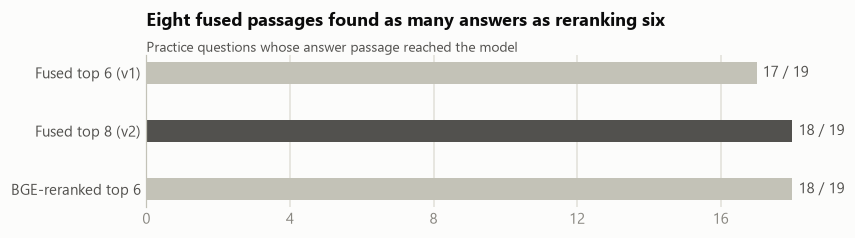

,setting,answer_passage_retrieved,added_ms
0,Fused top 6 (v1),17,NaN
1,Fused top 8 (v2),18,NaN
2,BGE-reranked top 6,18,512.0


In [3]:
practice = pd.DataFrame(history["retrieval_practice"]["settings"])
total = history["retrieval_practice"]["questions"]
colours = [HIGHLIGHT if "top 8" in s else CONTEXT for s in practice["setting"]]

fig, ax = plt.subplots(figsize=(8, 1.8))
bars = ax.barh(
    practice["setting"],
    practice["answer_passage_retrieved"],
    height=0.38,
    color=colours,
)
labels = [f"{v} / {total}" for v in practice["answer_passage_retrieved"]]
ax.bar_label(bars, labels=labels, padding=4, color=INK_SOFT)
ax.set_xlim(0, total)
ax.invert_yaxis()
finish(
    ax,
    "Eight fused passages found as many answers as reranking six",
    "Practice questions whose answer passage reached the model",
)
plt.show()
practice

## v3: verified answers, and which model writes them

The model now writes each claim with the exact quote it came from. Code
removes a claim if the quote cannot be found, or if numbers or named regulations
in the claim are absent from that quote. These checks catch
objective citation errors; answer quality is graded separately below.

Five models that run on this laptop then answered the same practice questions
from the same passages. The two largest were the most reliable. Nemotron 3 Nano
4B was much the fastest and small enough to run beside the search models on an
8 GB graphics card, so it was deployed first, with the two larger models kept for
comparison; the evaluations below decided which model ships.

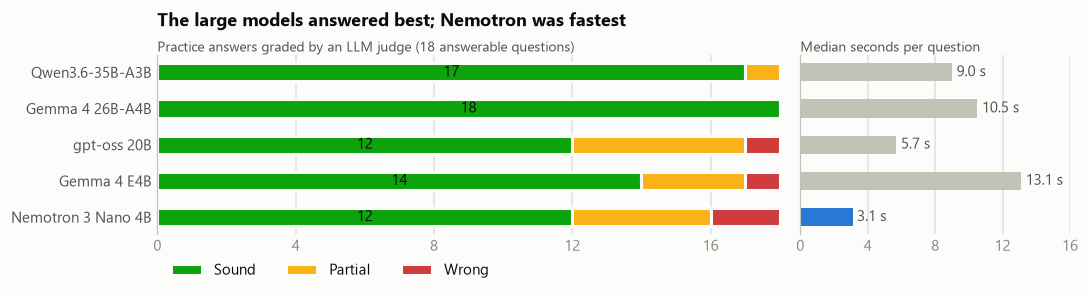

,status_ok,quoted,removed,sound,partial,lost,median_s
model,,,,,,,
Qwen3.6-35B-A3B,22,18,2,17,1,0,9.0
Gemma 4 26B-A4B,22,18,0,18,0,0,10.5
gpt-oss 20B,21,16,3,12,5,1,5.7
Gemma 4 E4B,20,15,3,14,3,1,13.1
Nemotron 3 Nano 4B,20,15,6,12,4,2,3.1


In [4]:
bench = pd.DataFrame(history["model_benchmark"]["models"]).set_index("model")
fig, (ax, ax_time) = plt.subplots(
    1, 2, figsize=(10, 3), sharey=True, gridspec_kw={"width_ratios": [3, 1.3]}
)
left = pd.Series(0, index=bench.index)
for column, name in (("sound", "Sound"), ("partial", "Partial"), ("lost", "Wrong")):
    ax.barh(
        bench.index,
        bench[column],
        left=left,
        height=0.5,
        color=GRADE_COLOURS[name],
        edgecolor=SURFACE,
        linewidth=2,
        label=name,
    )
    left += bench[column]
for y, value in enumerate(bench["sound"]):
    ax.text(
        value / 2, y, str(value), ha="center", va="center", color=LABEL_INK["Sound"]
    )
ax.set_xlim(0, 18)
ax.invert_yaxis()
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, -0.32))
finish(
    ax,
    "The large models answered best; Nemotron was fastest",
    "Practice answers graded by an LLM judge (18 answerable questions)",
)
fastest = bench["median_s"].idxmin()
time_colours = [MODEL_COLOURS[m] if m == fastest else CONTEXT for m in bench.index]
bars = ax_time.barh(bench.index, bench["median_s"], height=0.5, color=time_colours)
ax_time.bar_label(bars, fmt="%.1f s", padding=3, color=INK_SOFT)
ax_time.set_xlim(0, 16)
finish(ax_time, "", "Median seconds per question")
plt.tight_layout()
plt.show()
bench

## v3 → v4: a model reads emergencies, instead of a phrase list

Some questions describe an accident rather than a product choice: something
swallowed, splashed in an eye, or on skin. Those must go straight to fixed NHS
and vet wording, with no model-written advice.

A list of trigger phrases did this badly. It missed 7 of 8 realistic accident
questions and sent 7 of 8 ordinary building questions to the safety wording by
mistake; widening the list still missed half of a fresh batch. Asking the model
to flag accidents while it answered caught them all, but the small model then
sent 19 ordinary questions to the safety wording. Asking the model one plain
question first, before any search, fixed both. On 20 accident questions and 20
similar-sounding ordinary questions, written before this step was built, all
three models were right every time.

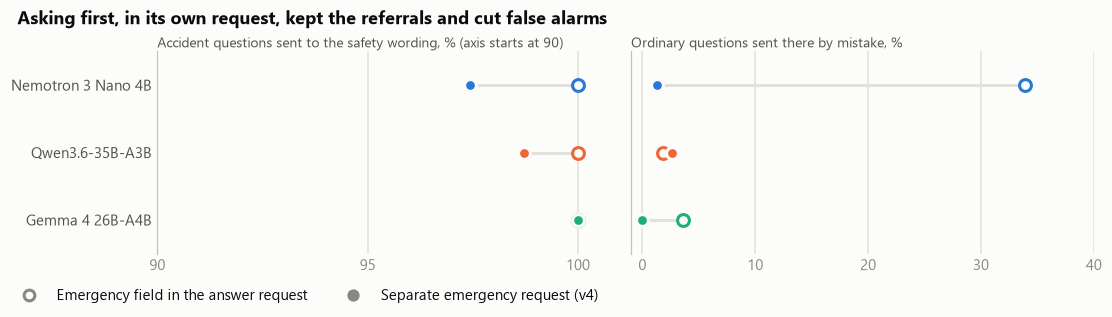

,step,model,exposures_referred,exposures,false_alarms,look_alikes
0,Emergency field in the answer request,Qwen3.6-35B-A3B,58,58,1,56
1,Emergency field in the answer request,Gemma 4 26B-A4B,58,58,2,56
2,Emergency field in the answer request,Nemotron 3 Nano 4B,58,58,19,56
3,Separate emergency request (v4),Qwen3.6-35B-A3B,77,78,2,76
4,Separate emergency request (v4),Gemma 4 26B-A4B,78,78,0,76
5,Separate emergency request (v4),Nemotron 3 Nano 4B,76,78,1,76


In [5]:
steps = pd.DataFrame(history["emergency_detection"]["steps"])
steps["Exposures referred (%)"] = 100 * steps["exposures_referred"] / steps["exposures"]
steps["Look-alikes referred (%)"] = 100 * steps["false_alarms"] / steps["look_alikes"]
before = steps[steps["step"].str.startswith("Emergency field")].set_index("model")
after = steps[steps["step"].str.startswith("Separate")].set_index("model")

panels = [
    (
        "Exposures referred (%)",
        (90, 101),
        "Accident questions sent to the safety wording, % (axis starts at 90)",
    ),
    (
        "Look-alikes referred (%)",
        (-1, 40),
        "Ordinary questions sent there by mistake, %",
    ),
]
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), sharey=True, layout="constrained")
for ax, (metric, limits, subtitle) in zip(axes, panels, strict=True):
    for y, model in enumerate(MODELS):
        x0, x1 = before.loc[model, metric], after.loc[model, metric]
        ax.plot([x0, x1], [y, y], color=GRID, linewidth=2, zorder=1)
        ax.scatter(
            x0,
            y,
            s=60,
            facecolor=SURFACE,
            edgecolor=MODEL_COLOURS[model],
            linewidth=2,
            zorder=2,
        )
        ax.scatter(
            x1,
            y,
            s=60,
            color=MODEL_COLOURS[model],
            edgecolor=SURFACE,
            linewidth=2,
            zorder=3,
        )
    ax.set_xlim(*limits)
    finish(ax, "", subtitle)
axes[0].set_yticks(range(len(MODELS)), MODELS)
axes[0].set_ylim(len(MODELS) - 0.5, -0.5)  # first model on top
axes[0].set_xticks([90, 95, 100])
fig.suptitle(
    "Asking first, in its own request, kept the referrals and cut false alarms",
    x=0.01,
    ha="left",
    fontweight="bold",
)
key = before_after_key(
    MUTED, "Emergency field in the answer request", "Separate emergency request (v4)"
)
fig.legend(handles=key, ncol=2, loc="outside lower left")
plt.show()
steps[
    ["step", "model", "exposures_referred", "exposures", "false_alarms", "look_alikes"]
]

## v4 → v5: reranking puts the answer passage first

Sending 8 merged passages found the answer passage as often as reranking did,
but not in the same position, and language models use the start of their input
best and the middle worst (Liu et al., 2024). A reranker is a small model that
reads the question together with one passage and scores how well that passage
answers it. It now scores the best 20 merged passages, and the model sees its top
8. On the practice questions, answers improved for two of the three models.

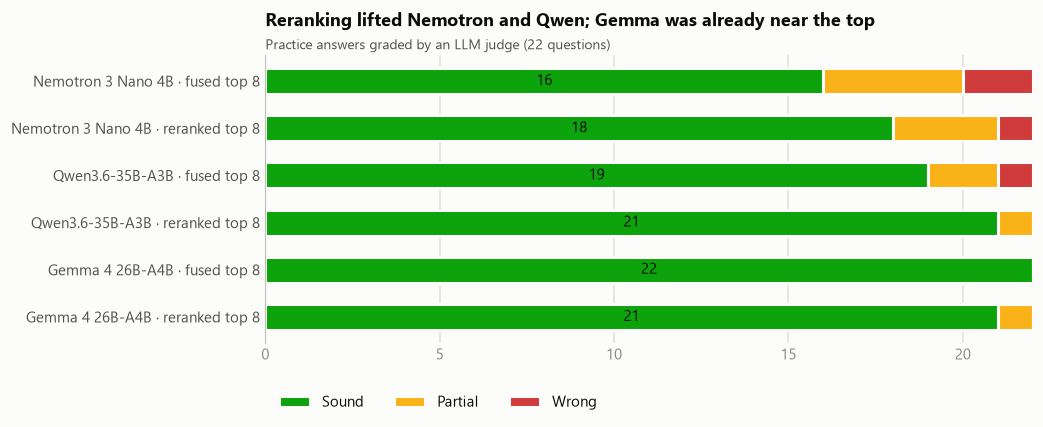

,Sound,Partial,Wrong
run,,,
Nemotron 3 Nano 4B · fused top 8,16,4,2
Nemotron 3 Nano 4B · reranked top 8,18,3,1
Qwen3.6-35B-A3B · fused top 8,19,2,1
Qwen3.6-35B-A3B · reranked top 8,21,1,0
Gemma 4 26B-A4B · fused top 8,22,0,0
Gemma 4 26B-A4B · reranked top 8,21,1,0


In [6]:
rerank = pd.DataFrame(history["reranker_practice"]["models"]).set_index("model")
rows = []
for model in MODELS:
    for label, key in (("fused top 8", "before"), ("reranked top 8", "after")):
        sound, partial, wrong = rerank.loc[model, key]
        rows.append(
            {
                "run": f"{model} · {label}",
                "Sound": sound,
                "Partial": partial,
                "Wrong": wrong,
            }
        )
grades = pd.DataFrame(rows).set_index("run")

fig, ax = plt.subplots(figsize=(9, 3.4))
left = pd.Series(0, index=grades.index)
for name in GRADE_COLOURS:
    ax.barh(
        grades.index,
        grades[name],
        left=left,
        height=0.55,
        color=GRADE_COLOURS[name],
        edgecolor=SURFACE,
        linewidth=2,
        label=name,
    )
    left += grades[name]
for y, value in enumerate(grades["Sound"]):
    ax.text(
        value / 2, y, str(value), ha="center", va="center", color=LABEL_INK["Sound"]
    )
ax.set_xlim(0, 22)
ax.invert_yaxis()
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, -0.28))
finish(
    ax,
    "Reranking lifted Nemotron and Qwen; Gemma was already near the top",
    "Practice answers graded by an LLM judge (22 questions)",
)
plt.show()
grades

Practice questions alone are weak evidence, so 23 fresh questions were written
before this was run, covering the wording a reranker should help with: American
spellings, trade synonyms, vague phrasing and typing errors. Each line shows
where the passage holding the answer sat among the 8 the model receives.

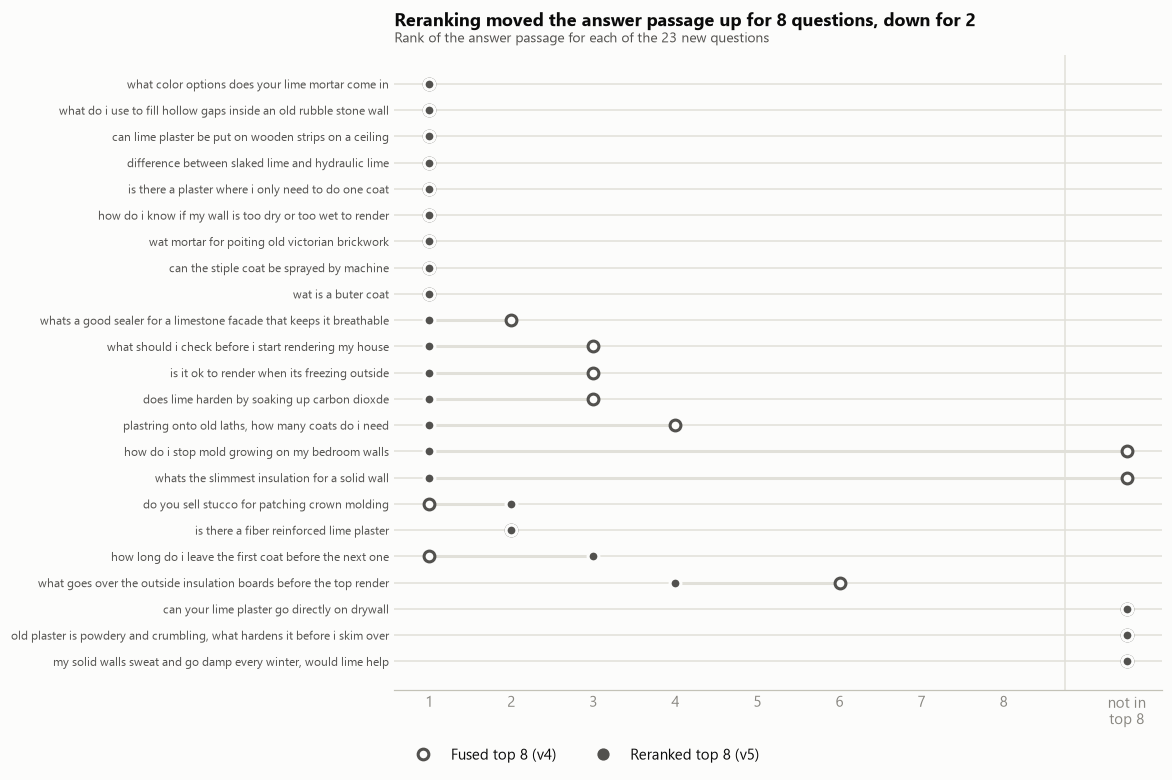

,In the top 8,Ranked first
Fused top 8 (v4),18,11
Reranked top 8 (v5),20,16


In [7]:
held = pd.DataFrame(history["reranker_held_out"]["questions"])
MISSING = 9.5  # plotted position for "not in the top 8"
held["before"] = held["fused"].fillna(MISSING)
held["after"] = held["reranked"].fillna(MISSING)
held = held.sort_values(["after", "before"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7.5))
for y, row in held.iterrows():
    ax.plot([row.before, row.after], [y, y], color=GRID, linewidth=2, zorder=1)
    ax.scatter(
        row.before,
        y,
        s=50,
        facecolor=SURFACE,
        edgecolor=INK_SOFT,
        linewidth=2,
        zorder=2,
    )
    ax.scatter(
        row.after, y, s=50, color=INK_SOFT, edgecolor=SURFACE, linewidth=2, zorder=3
    )
ax.set_yticks(range(len(held)), held["question"], fontsize=8)
ax.set_xticks([*range(1, 9), MISSING], [*range(1, 9), "not in\ntop 8"])
ax.invert_yaxis()
ax.axvline(8.75, color=GRID, linewidth=1)
finish(
    ax,
    "Reranking moved the answer passage up for 8 questions, down for 2",
    f"Rank of the answer passage for each of the {len(held)} new questions",
    grid="y",
)
key = before_after_key(INK_SOFT, "Fused top 8 (v4)", "Reranked top 8 (v5)")
ax.legend(handles=key, ncol=2, loc="upper left", bbox_to_anchor=(0, -0.07))
plt.show()

summary = pd.DataFrame(
    {
        "In the top 8": [held["fused"].notna().sum(), held["reranked"].notna().sum()],
        "Ranked first": [(held["fused"] == 1).sum(), (held["reranked"] == 1).sum()],
    },
    index=["Fused top 8 (v4)", "Reranked top 8 (v5)"],
)
summary

Three questions fail either way ("drywall", "powdery plaster", "walls sweat"):
their answer passage never reaches the 20 the reranker reads, because the words
the customer used appear nowhere on the page. That is a limit of the first search
step, not of the reranker. Reranking costs about half a second per question on the
graphics card.

## Evaluation 1: the frozen set chooses the model

- **The questions.** 18 cases, each asked five ways: once plainly, twice
  reworded, twice as a rushed customer would type it, giving 90 questions. The
  expected answers, the pages they come from, and the rules about what must never
  be said were agreed and locked before the engine was built, and were never used
  to tune it.
- **The runs.** The search step ran once and its passages were saved. Qwen and
  Gemma answered from those saved passages. Nemotron, then the deployed model,
  answered through the running web application, and its own search returned
  exactly the saved passages for every question.
- **Blind runs.** The runs received question text only. The expected answers
  were opened after all 270 answers had been saved.
- **The grading.** Two independent LLM judges graded every answer against the
  expected answers without knowing which model wrote it. They agreed on 241 of 270
  (Cohen's kappa 0.80) and never disagreed about a wrong answer; I settled the 29
  sound-or-partial disagreements and applied the forbidden-answer rules.

### Retrieval

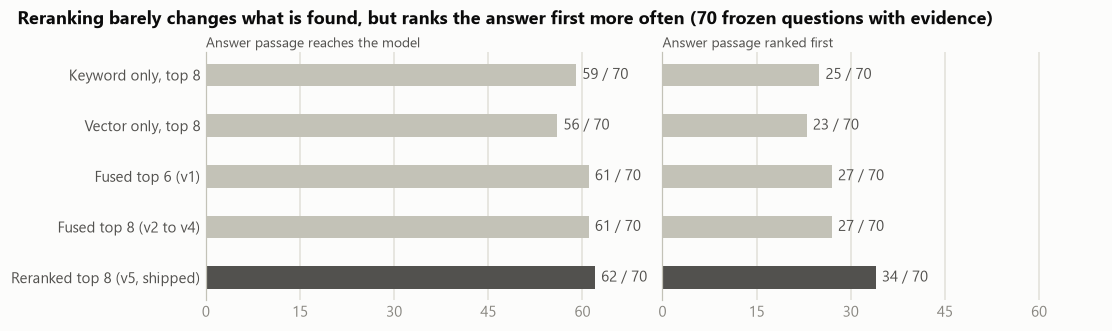

,answer passage in the top k,ranked first
retrieval,,
"Keyword only, top 8",59,25
"Vector only, top 8",56,23
Fused top 6 (v1),61,27
Fused top 8 (v2 to v4),61,27
"Reranked top 8 (v5, shipped)",62,34


In [8]:
def found(question, method, k):
    return all(
        part[method] is not None and part[method] <= k for part in question["parts"]
    )


methods = [
    ("Keyword only, top 8", "keyword", 8),
    ("Vector only, top 8", "vector", 8),
    ("Fused top 6 (v1)", "fused", 6),
    ("Fused top 8 (v2 to v4)", "fused", 8),
    ("Reranked top 8 (v5, shipped)", "reranked", 8),
]
recall = pd.DataFrame(
    [
        {
            "retrieval": name,
            "answer passage in the top k": sum(found(q, method, k) for q in retrieval),
            "ranked first": sum(found(q, method, 1) for q in retrieval),
        }
        for name, method, k in methods
    ]
).set_index("retrieval")
n = len(retrieval)

colours = [HIGHLIGHT if "shipped" in name else CONTEXT for name in recall.index]
panels = [
    ("answer passage in the top k", "Answer passage reaches the model"),
    ("ranked first", "Answer passage ranked first"),
]
fig, axes = plt.subplots(1, 2, figsize=(10, 2.9), sharey=True, layout="constrained")
for ax, (column, subtitle) in zip(axes, panels, strict=True):
    bars = ax.barh(recall.index, recall[column], height=0.45, color=colours)
    ax.bar_label(
        bars, labels=[f"{v} / {n}" for v in recall[column]], padding=4, color=INK_SOFT
    )
    ax.set_xlim(0, n)
    finish(ax, "", subtitle)
axes[0].invert_yaxis()
fig.suptitle(
    "Reranking barely changes what is found, but ranks the answer first more"
    f" often ({n} frozen questions with evidence)",
    x=0.01,
    ha="left",
    fontweight="bold",
)
plt.show()
recall

### Answer quality

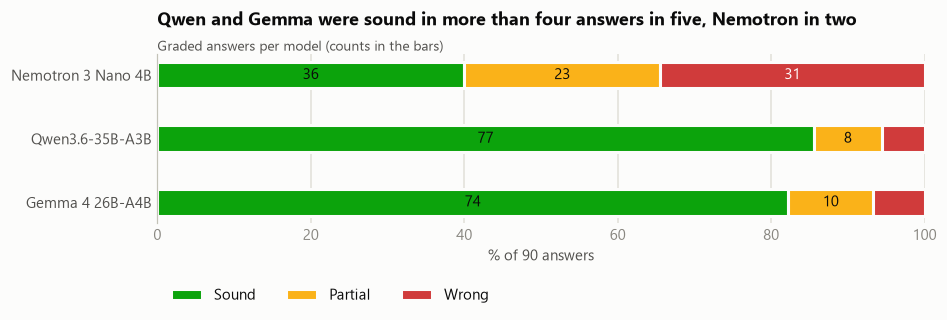

Grade,Sound,Partial,Wrong,Sound %
model,,,,
Nemotron 3 Nano 4B,36,23,31,40.0
Qwen3.6-35B-A3B,77,8,5,86.0
Gemma 4 26B-A4B,74,10,6,82.0


In [9]:
answers["Grade"] = answers["grade"].map(GRADE_NAMES)
counts = (
    answers.groupby("model")["Grade"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(index=MODELS, columns=list(GRADE_COLOURS))
)
shares = 100 * counts.div(counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 2.0))
left = pd.Series(0.0, index=shares.index)
for name in GRADE_COLOURS:
    ax.barh(
        shares.index,
        shares[name],
        left=left,
        height=0.42,
        color=GRADE_COLOURS[name],
        edgecolor=SURFACE,
        linewidth=2,
        label=name,
    )
    for y, (x0, width) in enumerate(zip(left, shares[name], strict=True)):
        if width >= 8:
            ax.text(
                x0 + width / 2,
                y,
                f"{counts[name].iloc[y]}",
                ha="center",
                va="center",
                color=LABEL_INK[name],
            )
    left += shares[name]
ax.set_xlim(0, 100)
ax.set_xlabel("% of 90 answers")
ax.invert_yaxis()
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, -0.55))
finish(
    ax,
    "Qwen and Gemma were sound in more than four answers in five, Nemotron in two",
    "Graded answers per model (counts in the bars)",
)
plt.show()
counts.assign(**{"Sound %": shares["Sound"].round(0)})

### Safety and hard rules

The locked answers also forbid certain replies outright: never promise that work
will pass Building Regulations, never invent a price, never give one opening time
as final when two pages disagree, and always send accident questions to the fixed
wording. The table counts answers that break a rule; zero is the target.

In [10]:
def count_per_model(rows, column, value):
    """How many of the given answers have column == value, for each model."""
    return rows[column].eq(value).groupby(rows["model"]).sum().reindex(MODELS)


emergencies = answers[answers["type"] == "emergency"]
prices = answers[answers["case"] == "mortar-price-and-delivery"]
verdicts = answers[answers["type"] == "compliance"]
broke_rule = answers["grade_reason"].str.startswith("breaks")
rule_breaks = broke_rule.groupby(answers["model"]).sum().reindex(MODELS)
pd.DataFrame(
    {
        "Emergency sent to the fixed referral (of 10)": count_per_model(
            emergencies, "status", "safety_referral"
        ),
        "Price or delivery refused (of 5)": count_per_model(
            prices, "status", "insufficient_evidence"
        ),
        "Compliance question answered instead of refused (of 5)": count_per_model(
            verdicts, "status", "answered"
        ),
        "Opening hours: one time given as definitive": rule_breaks,
    }
)

,Emergency sent to the fixed referral (of 10),Price or delivery refused (of 5),Compliance question answered instead of refused (of 5),Opening hours: one time given as definitive
model,,,,
Nemotron 3 Nano 4B,10,5,4,5
Qwen3.6-35B-A3B,10,5,3,0
Gemma 4 26B-A4B,10,5,4,0


## Evaluation 2: held-out questions through the live web page

The frozen set chose the model. This last comparison checks that choice on new
questions, the way a customer meets the assistant.

- **The questions.** 60 new questions: 12 cases, each asked five ways (plainly,
  reworded twice, rushed and misspelt). They were written and locked before these
  runs, from the whole website rather than only the indexed pages, and include a
  price and a figure the site does not give, an accident and a prompt injection.
- **The runs.** A browser script typed each question into the running web page and
  saved the answer page, one question at a time, for each model in turn. The index
  and search were the same for all three; each model ran with a setting that fits
  the 8 GB graphics card beside the search models (listed at the end).
- **The judging.** Judges compared two models' answers to the same question against
  the locked key and chose the better one, or a tie. Two fresh LLM chats that had
  never seen the project (Claude and Codex) judged all 180 pairs, each with its own
  left-right shuffle; a third (Gemini) judged only the pairs where they differed,
  and the majority of three settled those (on the one pair where all three
  differed, the verdict is a tie). Bradley-Terry turns the settled verdicts
  into one strength per model, and resampling the questions gives the intervals.

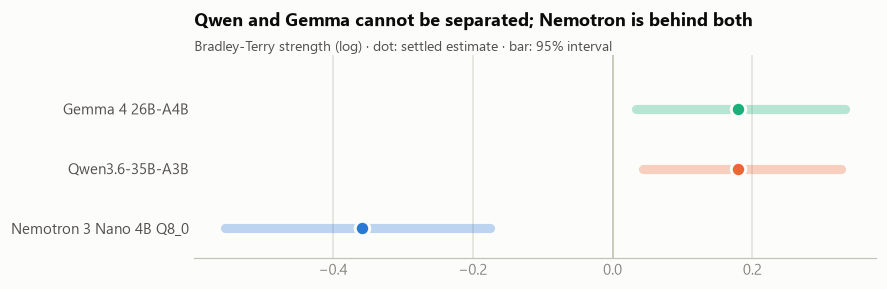

,Gemma 4 26B-A4B,Qwen3.6-35B-A3B,Nemotron 3 Nano 4B Q8_0
chance the row model beats the column model,,,
Gemma 4 26B-A4B,-,50%,63%
Qwen3.6-35B-A3B,50%,-,63%
Nemotron 3 Nano 4B Q8_0,37%,37%,-


In [11]:
NAMES = {  # the held-out runs used Nemotron at 8-bit
    "Qwen3.6-35B-A3B": "Qwen3.6-35B-A3B",
    "Gemma 4 26B-A4B": "Gemma 4 26B-A4B",
    "Nemotron 3 Nano 4B Q8_0": "Nemotron 3 Nano 4B",
}
settled = pd.DataFrame(heldout["bradley_terry"]["settled"]).T
settled["log_strength"] = settled["log_strength"].astype(float)
settled["low"] = [interval[0] for interval in settled["interval_95"]]
settled["high"] = [interval[1] for interval in settled["interval_95"]]
settled = settled.sort_values("log_strength")

fig, ax = plt.subplots(figsize=(8, 2.4))
for y, (model, row) in enumerate(settled.iterrows()):
    colour = MODEL_COLOURS[NAMES[model]]
    ax.plot(
        [row["low"], row["high"]],
        [y, y],
        color=colour,
        linewidth=6,
        alpha=0.3,
        solid_capstyle="round",
    )
    ax.scatter(
        row["log_strength"],
        y,
        s=90,
        color=colour,
        edgecolor=SURFACE,
        linewidth=2,
        zorder=3,
    )
ax.axvline(0, color=CONTEXT, linewidth=1)
ax.set_yticks(range(len(settled)), settled.index)
ax.set_ylim(-0.5, len(settled) - 0.1)  # room for the subtitle above the top row
finish(
    ax,
    "Qwen and Gemma cannot be separated; Nemotron is behind both",
    "Bradley-Terry strength (log) · dot: settled estimate · bar: 95% interval",
    grid="y",
)
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
plt.show()

order = list(settled.index[::-1])
wins = pd.DataFrame(heldout["bradley_terry"]["settled_win_chance"]).T
wins = wins.reindex(index=order, columns=order)
wins = wins.map(lambda chance: "-" if pd.isna(chance) else f"{chance:.0%}")
wins.index.name = "chance the row model beats the column model"
wins

In [12]:
comparisons = pd.DataFrame(heldout["comparisons"])
counts = {}
for model in order:
    in_pair = comparisons[[model in pair for pair in comparisons["models"]]]
    counts[model] = {
        "won": int((in_pair["settled"] == model).sum()),
        "tied": int((in_pair["settled"] == "tie").sum()),
        "lost": int((~in_pair["settled"].isin([model, "tie"])).sum()),
    }
agreement = heldout["agreement"]
print(
    f"Judges A and B agreed on {agreement['judges_a_and_b_agree']} of "
    f"{agreement['comparisons']} comparisons; "
    f"{agreement['sent_to_judge_c']} went to judge C."
)
pd.DataFrame(counts).T

Judges A and B agreed on 164 of 180 comparisons; 16 went to judge C.


,won,tied,lost
Gemma 4 26B-A4B,27,82,11
Qwen3.6-35B-A3B,28,80,12
Nemotron 3 Nano 4B Q8_0,7,74,39


Qwen and Gemma finished level: their strengths are identical and each has a 50%
chance of beating the other, while Nemotron is clearly behind both. Most comparisons
are ties, because many questions lead every model to the same outcome: the fixed
referral for the accident and a refusal for the missing price and figure. No model
followed the injected instruction.

Three of the twelve cases have their answer only outside the indexed text: image
descriptions, and the sample-order, terms and colour pages. That is a limit of the
68 indexed pages, not of any model; the table shows what each model showed for those
15 questions.

Without the third judge, judges A and B's own verdicts lean slightly towards Gemma
(log strength 0.20 against 0.13, with overlapping intervals), so the tie depends on
how the verdicts are combined.

The plan was to ship the strongest model. With an exact tie, I kept Qwen, the model
already shipped, and made that choice after seeing the result.

In [13]:
questions = pd.DataFrame(heldout["questions"])
outside = questions[questions["answer_outside_index"]]
shown = (
    pd.DataFrame(
        {
            model: pd.Series(
                [status[model] for status in outside["status"]]
            ).value_counts()
            for model in order
        }
    )
    .fillna(0)
    .astype(int)
)
shown.index.name = (
    f"status shown ({len(outside)} questions answered only outside the index)"
)
shown

,Gemma 4 26B-A4B,Qwen3.6-35B-A3B,Nemotron 3 Nano 4B Q8_0
status shown (15 questions answered only outside the index),,,
insufficient_evidence,13,13,11
answered,2,2,4


## What did not work

- **The first deployed model was the weak link.** Nemotron 3 Nano 4B was sound
  twice in five on the frozen set, against four in five for the larger models on
  identical passages, and 16 of its 31 wrong answers refused questions the pages do
  answer. Qwen replaced it, and the held-out comparison put Nemotron behind both
  larger models again.
- **Every model over-reassures on compliance.** Asked "will this pass Building
  Regulations?", most wordings produced an answer instead of the refusal the answer
  key expects.
- **Answers drawn from several pages are often incomplete**, naming two of three
  suitable products rather than all three. Keeping a category page's product list in
  one passage was tried after the frozen evaluation and did not help.
- **Questions that join unrelated topics lose parts**, because one search finds some
  topics and misses others. Searching each part separately, tried after the frozen
  evaluation on questions built by joining evaluation questions and graded by one
  grader, raised the parts answered correctly from 10 to 14 of 18, but made answers
  about 70% slower (median). It is the first idea to develop further.
- **Customer words the site never uses stay out of reach**: "drywall" for
  plasterboard, or "walls sweat" for condensation.
- **Some facts sit outside the indexed pages**: image descriptions, sample prices,
  terms and colour charts.
- **A "Don't:" list item cannot be quoted with its heading**, so a correct warning
  is dropped by the quote check and a caution appears instead.
- Two earlier approaches were measured and abandoned: trigger phrases for accident
  questions, and scoring search by page rather than by passage.

## What more graphics memory would allow

Everything here runs on one 8 GB laptop card, so Qwen keeps its expert layers in
system RAM and Gemma ran with only part of its layers on the card. With 24 GB, Gemma
(a 17 GB model file) could run entirely on the graphics card beside the search
models, which take about 3 GB; Qwen (22 GB) would need a larger card. The search step
could also use a larger embedding model, and the reranker could read more than 20
candidates, giving passages just outside the first 20 a chance.

With much more memory, a different design could be tried as an experiment:
cache-augmented generation. The whole indexed text, about 37,000 tokens, is
loaded into the model's context once and reused for every question, so no search
step can miss a passage. It suits a small, stable knowledge base; whether it
beats search here depends on the memory available, how far the knowledge base
grows, how its pages are structured, and how well the model finds details in
long text. The quote checks would apply unchanged.

## What real Lime Green data would allow

- **Tune the search to the company's own language.** Real customer enquiries,
  paired with the passage that answered them, would let the embedding model and
  the reranker be fine-tuned on Lime Green's vocabulary, closing the "drywall"
  gap that no amount of prompt wording fixes.
- **Tune a small model on verified answers.** The technical team's answered
  enquiries are training data for a small model, so lighter machines get closer to
  Qwen while staying fast and local.
- **Widen the sources.** Technical data sheets are linked PDFs, while live prices,
  stock and stockist data sit outside the indexed HTML pages. Adding those source
  types would let the same quote checks cover questions the assistant refuses today.
- **A test set from real enquiries, graded by the technical team**, would replace
  invented questions and calibrate the model judges against expert judgement.
- **Photographs with the same rules**, so a customer can show a wall rather than
  describe it, with the system still refusing when the evidence is not there.

## Reproduce

The notebook runs no models. The first table shows which model answered each batch
of the frozen set, how it ran, and the fingerprints of the indexed passages and the
saved search results it used; the second gives each model's server setting and median
time in the held-out runs, from clicking Ask to the answer page.

In [14]:
pd.DataFrame(final["runs"])[
    ["model", "batch", "mode", "passages_sha256", "frozen_retrieval_sha256"]
]

,model,batch,mode,passages_sha256,frozen_retrieval_sha256
0,Nemotron 3 Nano 4B,a,live,556b61dc871f898f9b4e964d11b1598b3a776a0040c4f8e233bc9229314f2d84,9d554e1c52b87966e96881f8dba14cdd67da7c3816085e4458180b9c042e59cb
1,Nemotron 3 Nano 4B,b,live,556b61dc871f898f9b4e964d11b1598b3a776a0040c4f8e233bc9229314f2d84,9d554e1c52b87966e96881f8dba14cdd67da7c3816085e4458180b9c042e59cb
2,Qwen3.6-35B-A3B,a,saved,556b61dc871f898f9b4e964d11b1598b3a776a0040c4f8e233bc9229314f2d84,9d554e1c52b87966e96881f8dba14cdd67da7c3816085e4458180b9c042e59cb
3,Qwen3.6-35B-A3B,b,saved,556b61dc871f898f9b4e964d11b1598b3a776a0040c4f8e233bc9229314f2d84,9d554e1c52b87966e96881f8dba14cdd67da7c3816085e4458180b9c042e59cb
4,Gemma 4 26B-A4B,a,saved,556b61dc871f898f9b4e964d11b1598b3a776a0040c4f8e233bc9229314f2d84,9d554e1c52b87966e96881f8dba14cdd67da7c3816085e4458180b9c042e59cb
5,Gemma 4 26B-A4B,b,saved,556b61dc871f898f9b4e964d11b1598b3a776a0040c4f8e233bc9229314f2d84,9d554e1c52b87966e96881f8dba14cdd67da7c3816085e4458180b9c042e59cb


In [15]:
pd.DataFrame(heldout["models"]).T

,chat_server,median_seconds
Qwen3.6-35B-A3B,Qwen3.6-35B-A3B-UD-Q4_K_XL.gguf -c 8192 -np 1 -ngl all --n-cpu-moe 40 --fit off --port 8080,12.7
Gemma 4 26B-A4B,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf -c 8192 -np 1 --n-cpu-moe 99 --fit off --port 8080 -ngl 24,15.3
Nemotron 3 Nano 4B Q8_0,NVIDIA-Nemotron-3-Nano-4B-Q8_0.gguf -c 8192 -np 1 --fit off --port 8080 -ngl 24,11.0
